In [4]:
"""
================================================================================
v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK
================================================================================
Version: 18 (Liver/Blood tissue-separated re-analysis)
Dataset: GSE182159 (243K cells, 23 donors, 46 samples)
Purpose: Establish tissue separation, validate data structure,
         generate baseline statistics for Liver-only and Blood-only
Save path: /content/drive/MyDrive/ITLAS/results/version18-analysis/
================================================================================
"""

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 150
import os
import warnings
warnings.filterwarnings('ignore')



In [8]:
# =================================================================
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ============================================================
# 0. SETUP: Create output directory
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/C0_data_framework/', exist_ok=True)

print("=" * 70)
print("v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK")
print("=" * 70)

v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK


In [6]:
# ============================================================
# 1. LOAD DATA
# ============================================================
DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
print(f"\nLoading: {DATA_PATH}")
adata = sc.read_h5ad(DATA_PATH)
print(f"Total cells: {adata.n_obs:,}")
print(f"Total genes: {adata.n_vars:,}")


Loading: /content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad
Total cells: 243,000
Total genes: 24,452


In [9]:
# ============================================================
# 2. VALIDATE KEY COLUMNS
# ============================================================
print("\n" + "=" * 70)
print("KEY COLUMNS VALIDATION")
print("=" * 70)

required_cols = ['tissue', 'Stage', 'major_lineage', 'sample', 'donor']
for col in required_cols:
    if col in adata.obs.columns:
        vals = adata.obs[col].unique()
        print(f"\n✅ '{col}': {len(vals)} unique values")
        if len(vals) <= 10:
            print(f"   Values: {sorted(vals.tolist())}")
    else:
        print(f"\n❌ '{col}': NOT FOUND — CRITICAL ERROR")

# Donor column: if not present, extract from sample
if 'donor' not in adata.obs.columns:
    print("\n⚠️ 'donor' column not found. Extracting from 'sample'...")
    adata.obs['donor'] = adata.obs['sample'].apply(lambda x: x.split('_')[1])
    print(f"   Extracted donors: {sorted(adata.obs['donor'].unique().tolist())}")



KEY COLUMNS VALIDATION

✅ 'tissue': 2 unique values
   Values: ['Blood', 'Liver']

✅ 'Stage': 5 unique values
   Values: ['AR', 'CR', 'IA', 'IT', 'NL']

✅ 'major_lineage': 7 unique values
   Values: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']

✅ 'sample': 46 unique values

❌ 'donor': NOT FOUND — CRITICAL ERROR

⚠️ 'donor' column not found. Extracting from 'sample'...
   Extracted donors: ['D528848', 'D529074', 'D529351', 'D529354', 'D529409', 'Dhc570', 'P190326', 'P190402', 'P190604', 'P190716', 'P190719', 'P190801', 'P190808', 'P190902', 'P190910', 'P190911', 'P191008', 'P191028', 'P191112', 'P191126', 'P191127', 'P191210', 'P191217']


In [10]:
# ============================================================
# 3. TISSUE DISTRIBUTION: Overall
# ============================================================
print("\n" + "=" * 70)
print("TISSUE DISTRIBUTION: OVERALL")
print("=" * 70)

tissue_counts = adata.obs['tissue'].value_counts()
print(f"\nLiver cells: {tissue_counts.get('Liver', 0):,} ({tissue_counts.get('Liver', 0)/adata.n_obs*100:.1f}%)")
print(f"Blood cells: {tissue_counts.get('Blood', 0):,} ({tissue_counts.get('Blood', 0)/adata.n_obs*100:.1f}%)")



TISSUE DISTRIBUTION: OVERALL

Liver cells: 106,592 (43.9%)
Blood cells: 136,408 (56.1%)


In [11]:
# ============================================================
# 4. TISSUE × STAGE DISTRIBUTION
# ============================================================
print("\n" + "=" * 70)
print("TISSUE × STAGE DISTRIBUTION")
print("=" * 70)

tissue_stage = adata.obs.groupby(['tissue', 'Stage']).size().unstack(fill_value=0)
print("\nCell counts:")
print(tissue_stage.to_string())

# Proportions within each tissue
tissue_stage_pct = tissue_stage.div(tissue_stage.sum(axis=1), axis=0) * 100
print("\nProportions (% within tissue):")
print(tissue_stage_pct.round(1).to_string())

# Liver:Blood ratio per stage
print("\nLiver:Blood ratio per stage:")
for stage in tissue_stage.columns:
    liver_n = tissue_stage.loc['Liver', stage] if 'Liver' in tissue_stage.index else 0
    blood_n = tissue_stage.loc['Blood', stage] if 'Blood' in tissue_stage.index else 0
    ratio = liver_n / blood_n if blood_n > 0 else float('inf')
    print(f"  {stage}: Liver={liver_n:,}, Blood={blood_n:,}, ratio={ratio:.2f}")


TISSUE × STAGE DISTRIBUTION

Cell counts:
Stage      CR     AR     IA     IT     NL
tissue                                   
Blood   30408  27706  30256  29678  18360
Liver   12837  17746  32289  19501  24219

Proportions (% within tissue):
Stage     CR    AR    IA    IT    NL
tissue                              
Blood   22.3  20.3  22.2  21.8  13.5
Liver   12.0  16.6  30.3  18.3  22.7

Liver:Blood ratio per stage:
  CR: Liver=12,837, Blood=30,408, ratio=0.42
  AR: Liver=17,746, Blood=27,706, ratio=0.64
  IA: Liver=32,289, Blood=30,256, ratio=1.07
  IT: Liver=19,501, Blood=29,678, ratio=0.66
  NL: Liver=24,219, Blood=18,360, ratio=1.32


In [12]:
# ============================================================
# 5. TISSUE × STAGE × LINEAGE DISTRIBUTION
# ============================================================
print("\n" + "=" * 70)
print("TISSUE × STAGE × LINEAGE DISTRIBUTION")
print("=" * 70)

# Full cross-tabulation
full_crosstab = adata.obs.groupby(['tissue', 'Stage', 'major_lineage']).size().reset_index(name='count')
full_pivot = full_crosstab.pivot_table(index=['tissue', 'major_lineage'], columns='Stage', values='count', fill_value=0)
# Reorder stages
stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
stage_cols = [s for s in stage_order if s in full_pivot.columns]
full_pivot = full_pivot[stage_cols]
print(full_pivot.to_string())

# Save as CSV
full_pivot.to_csv(f'{SAVE_DIR}/C0_data_framework/tissue_stage_lineage_counts.csv')
print(f"\n✅ Saved: tissue_stage_lineage_counts.csv")


TISSUE × STAGE × LINEAGE DISTRIBUTION
Stage                     NL       IT       IA      AR       CR
tissue major_lineage                                           
Blood  B              1864.0   3441.0   3791.0  2093.0   6702.0
       CD4_T          4067.0  10193.0  10455.0  9206.0  11317.0
       CD8_T          3346.0   3886.0   5924.0  6079.0   4701.0
       Myeloid        2113.0   5182.0   4986.0  3996.0   4947.0
       NK             6877.0   6695.0   4827.0  6087.0   2457.0
       PlasmaB          68.0    197.0    213.0   229.0    259.0
       gdT              25.0     84.0     60.0    16.0     25.0
Liver  B               646.0    566.0   1428.0   233.0    561.0
       CD4_T          4581.0   4398.0   7925.0  4322.0   2982.0
       CD8_T          8628.0   7052.0  14933.0  9730.0   5786.0
       Myeloid         259.0   1121.0   1581.0   217.0    314.0
       NK             9286.0   6125.0   6158.0  3078.0   2994.0
       PlasmaB         634.0    168.0    145.0    63.0    107.0
 

In [13]:
# ============================================================
# 6. DONOR MAPPING: Tissue × Stage × Donor
# ============================================================
print("\n" + "=" * 70)
print("DONOR MAPPING")
print("=" * 70)

donor_info = adata.obs.groupby(['donor', 'Stage', 'tissue']).size().reset_index(name='cell_count')
donor_pivot = donor_info.pivot_table(index=['donor', 'Stage'], columns='tissue', values='cell_count', fill_value=0)
print(donor_pivot.to_string())
donor_pivot.to_csv(f'{SAVE_DIR}/C0_data_framework/donor_tissue_mapping.csv')
print(f"\n✅ Saved: donor_tissue_mapping.csv")

# Verify: every donor has both Liver and Blood
print("\nDonor tissue completeness check:")
for donor in sorted(adata.obs['donor'].unique()):
    tissues = adata.obs[adata.obs['donor'] == donor]['tissue'].unique()
    has_both = 'Liver' in tissues and 'Blood' in tissues
    status = "✅ Both" if has_both else "❌ MISSING"
    print(f"  {donor}: {status} ({sorted(tissues.tolist())})")



DONOR MAPPING
tissue           Blood    Liver
donor   Stage                  
D528848 CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0      0.0
        NL      8149.0   4733.0
D529074 CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0      0.0
        NL      6843.0   5956.0
D529351 CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0      0.0
        NL      1988.0    690.0
D529354 CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0      0.0
        NL       720.0   5233.0
D529409 CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0      0.0
        NL       660.0   3364.0
Dhc570  CR         0.0      0.0
        AR         0.0      0.0
        IA         0.0      0.0
        IT         0.0   

In [14]:
# ============================================================
# 7. DONOR COUNTS PER STAGE (for statistical pair counts)
# ============================================================
print("\n" + "=" * 70)
print("DONOR COUNTS PER STAGE (for Mann-Whitney pair counts)")
print("=" * 70)

for tissue in ['Liver', 'Blood']:
    print(f"\n--- {tissue} ---")
    mask = adata.obs['tissue'] == tissue
    donors_per_stage = adata.obs[mask].groupby('Stage')['donor'].nunique()
    for stage in stage_order:
        if stage in donors_per_stage.index:
            n = donors_per_stage[stage]
            print(f"  {stage}: n={n} donors")

    # Pair counts
    n_NL = donors_per_stage.get('NL', 0)
    n_IT = donors_per_stage.get('IT', 0)
    n_IA = donors_per_stage.get('IA', 0)
    n_AR = donors_per_stage.get('AR', 0)
    n_CR = donors_per_stage.get('CR', 0)
    print(f"  Pairs: NL→IT={n_NL*n_IT}, NL→IA={n_NL*n_IA}, NL→AR={n_NL*n_AR}, NL→CR={n_NL*n_CR}, IT→IA={n_IT*n_IA}")



DONOR COUNTS PER STAGE (for Mann-Whitney pair counts)

--- Liver ---
  NL: n=6 donors
  IT: n=6 donors
  IA: n=5 donors
  AR: n=3 donors
  CR: n=3 donors
  Pairs: NL→IT=36, NL→IA=30, NL→AR=18, NL→CR=18, IT→IA=30

--- Blood ---
  NL: n=5 donors
  IT: n=5 donors
  IA: n=4 donors
  AR: n=3 donors
  CR: n=3 donors
  Pairs: NL→IT=25, NL→IA=20, NL→AR=15, NL→CR=15, IT→IA=20


In [15]:
# ============================================================
# 8. LINEAGE PROPORTIONS BY TISSUE AND STAGE
# ============================================================
print("\n" + "=" * 70)
print("LINEAGE PROPORTIONS (%) BY TISSUE AND STAGE")
print("=" * 70)

for tissue in ['Liver', 'Blood']:
    print(f"\n{'='*50}")
    print(f"  {tissue.upper()}")
    print(f"{'='*50}")
    mask = adata.obs['tissue'] == tissue
    prop = adata.obs[mask].groupby('Stage')['major_lineage'].value_counts(normalize=True).unstack(fill_value=0) * 100
    prop = prop.reindex(stage_order)
    print(prop.round(1).to_string())


LINEAGE PROPORTIONS (%) BY TISSUE AND STAGE

  LIVER
major_lineage    B  CD4_T  CD8_T  Myeloid    NK  PlasmaB  gdT
Stage                                                        
NL             2.7   18.9   35.6      1.1  38.3      2.6  0.8
IT             2.9   22.6   36.2      5.7  31.4      0.9  0.4
IA             4.4   24.5   46.2      4.9  19.1      0.4  0.4
AR             1.3   24.4   54.8      1.2  17.3      0.4  0.6
CR             4.4   23.2   45.1      2.4  23.3      0.8  0.7

  BLOOD
major_lineage     B  CD4_T  CD8_T  Myeloid    NK  PlasmaB  gdT
Stage                                                         
NL             10.2   22.2   18.2     11.5  37.5      0.4  0.1
IT             11.6   34.3   13.1     17.5  22.6      0.7  0.3
IA             12.5   34.6   19.6     16.5  16.0      0.7  0.2
AR              7.6   33.2   21.9     14.4  22.0      0.8  0.1
CR             22.0   37.2   15.5     16.3   8.1      0.9  0.1


In [16]:
# ============================================================
# 9. SAMPLE ID MAPPING TABLE
# ============================================================
print("\n" + "=" * 70)
print("SAMPLE ID MAPPING")
print("=" * 70)

sample_info = adata.obs.groupby('sample').agg(
    tissue=('tissue', 'first'),
    stage=('Stage', 'first'),
    donor=('donor', 'first'),
    n_cells=('tissue', 'size')
).sort_values(['donor', 'tissue'])
print(sample_info.to_string())
sample_info.to_csv(f'{SAVE_DIR}/C0_data_framework/sample_id_mapping.csv')
print(f"\n✅ Saved: sample_id_mapping.csv")


SAMPLE ID MAPPING
                           tissue stage    donor  n_cells
sample                                                   
GSM5519478_D528848_Blood_1  Blood    NL  D528848     8149
GSM5519484_D528848_Liver_1  Liver    NL  D528848     4733
GSM5519479_D529074_Blood_1  Blood    NL  D529074     6843
GSM5519485_D529074_Liver_1  Liver    NL  D529074     5956
GSM5519480_D529351_Blood_1  Blood    NL  D529351     1988
GSM5519486_D529351_Liver_1  Liver    NL  D529351      690
GSM5519481_D529354_Blood_1  Blood    NL  D529354      720
GSM5519487_D529354_Liver_1  Liver    NL  D529354     5233
GSM5519482_D529409_Blood_1  Blood    NL  D529409      660
GSM5519488_D529409_Liver_1  Liver    NL  D529409     3364
GSM5519483_Dhc570_Liver_1   Liver    NL   Dhc570     4243
GSM5519470_P190326_Blood_1  Blood    IT  P190326     3674
GSM5519471_P190326_Liver_1  Liver    IT  P190326     1379
GSM5519472_P190402_Liver_1  Liver    IT  P190402     7110
GSM5519467_P190604_Blood_1  Blood    IT  P190604     

In [17]:
# ============================================================
# 10. SUBCLUSTER DISTRIBUTION BY TISSUE
# ============================================================
print("\n" + "=" * 70)
print("59 SUBCLUSTERS: TISSUE DISTRIBUTION")
print("=" * 70)

subcluster_col = 'gut2021_subcluster_v2' if 'gut2021_subcluster_v2' in adata.obs.columns else 'gut2021_subcluster'
print(f"Using subcluster column: {subcluster_col}")

sc_tissue = adata.obs.groupby([subcluster_col, 'tissue']).size().unstack(fill_value=0)
sc_tissue['total'] = sc_tissue.sum(axis=1)
sc_tissue['liver_pct'] = (sc_tissue.get('Liver', 0) / sc_tissue['total'] * 100).round(1)
sc_tissue = sc_tissue.sort_values('total', ascending=False)
print(sc_tissue.head(20).to_string())
sc_tissue.to_csv(f'{SAVE_DIR}/C0_data_framework/subcluster_tissue_distribution.csv')
print(f"\n✅ Saved: subcluster_tissue_distribution.csv")


59 SUBCLUSTERS: TISSUE DISTRIBUTION
Using subcluster column: gut2021_subcluster_v2
tissue                 Blood  Liver  total  liver_pct
gut2021_subcluster_v2                                
CD4T_c01-LEF1          20452    310  20762        1.5
NK_c02-KLRC2            7915   4426  12341       35.9
CD4T_c02-ANXA2          9444   1865  11309       16.5
NK_c03-PTGDS            7687   3409  11096       30.7
mono_c01-CD14           9472    627  10099        6.2
NK_c01-GZMK              265   8842   9107       97.1
CD8T_c03-CX3CR1         6110   2370   8480       27.9
CD8T_c11-SLC4A10         724   7590   8314       91.3
CD8T_c07-GZMK-PDCD1      228   7791   8019       97.2
CD8T_c08-LAYN            527   7169   7696       93.2
NK_c05-ITGAX            6080   1262   7342       17.2
B_c01-IGHD              6894    351   7245        4.8
CD4T_c03-GNLY           3812   3010   6822       44.1
CD4T_c06-IFI44L         5592    978   6570       14.9
CD8T_c04-GZMK-SIRPG      935   5548   6483       85.


GENERATING FIGURES...


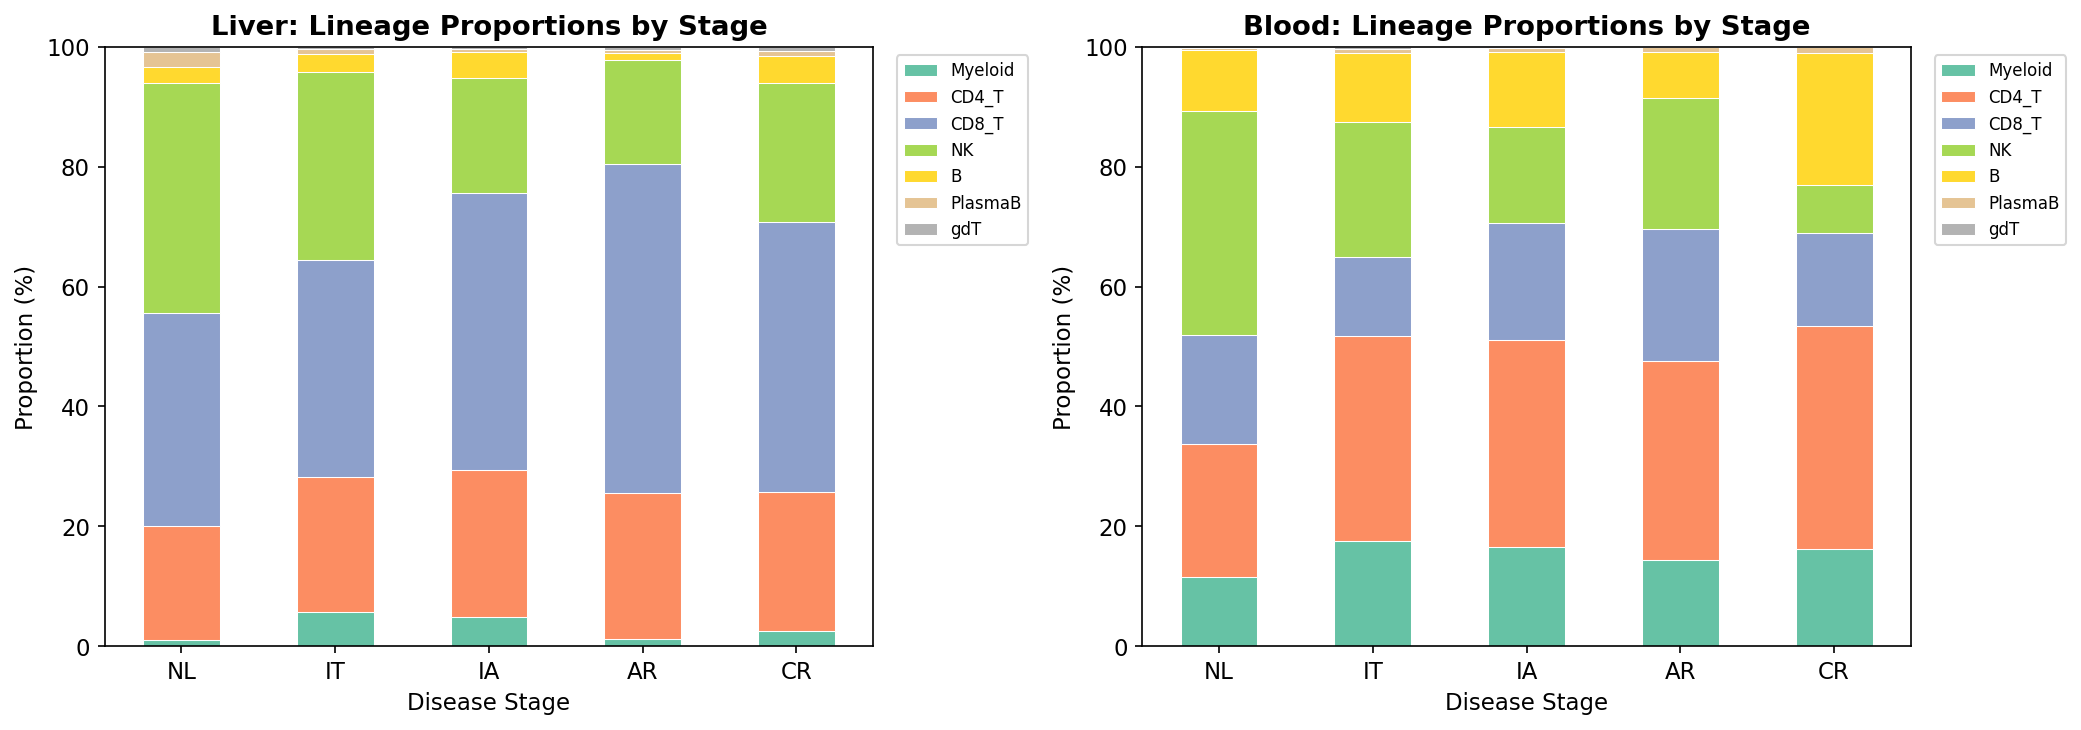

✅ Saved: fig_C0_1_lineage_proportions_by_tissue.png


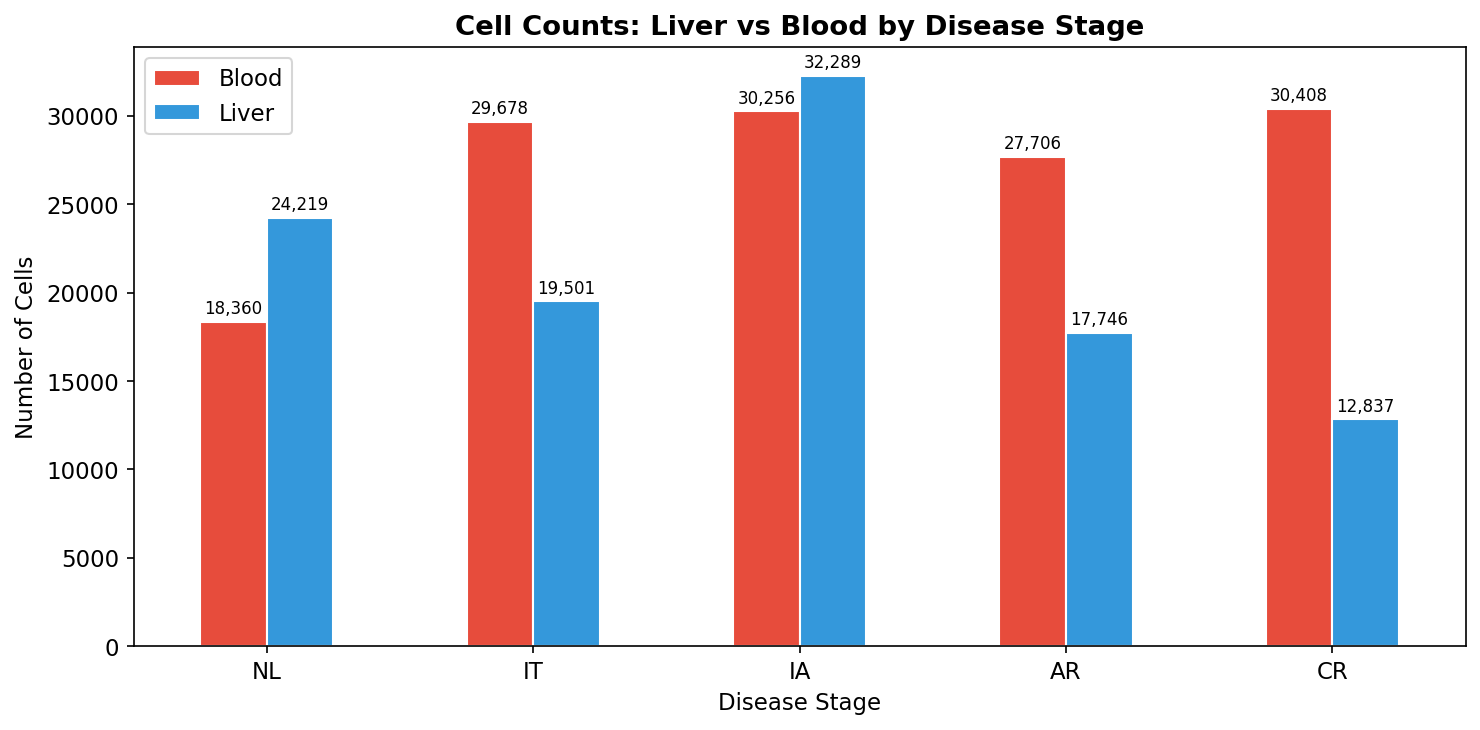

✅ Saved: fig_C0_2_liver_blood_cellcounts.png


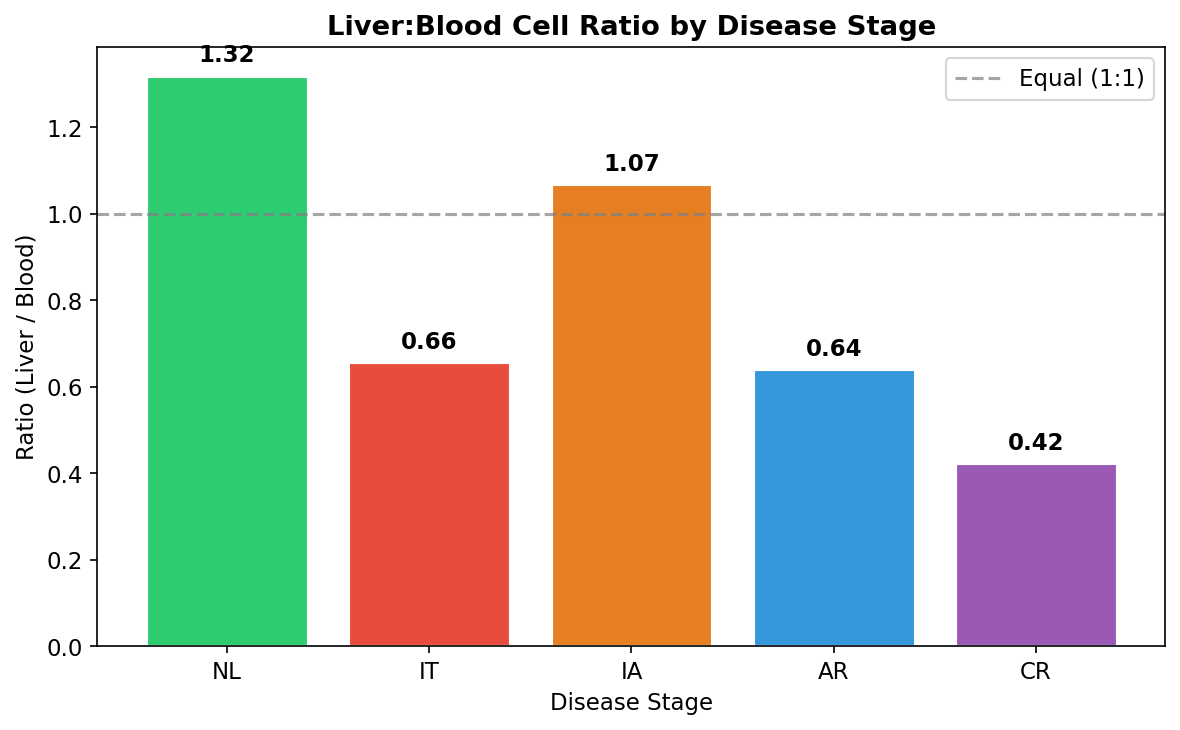

✅ Saved: fig_C0_3_liver_blood_ratio.png


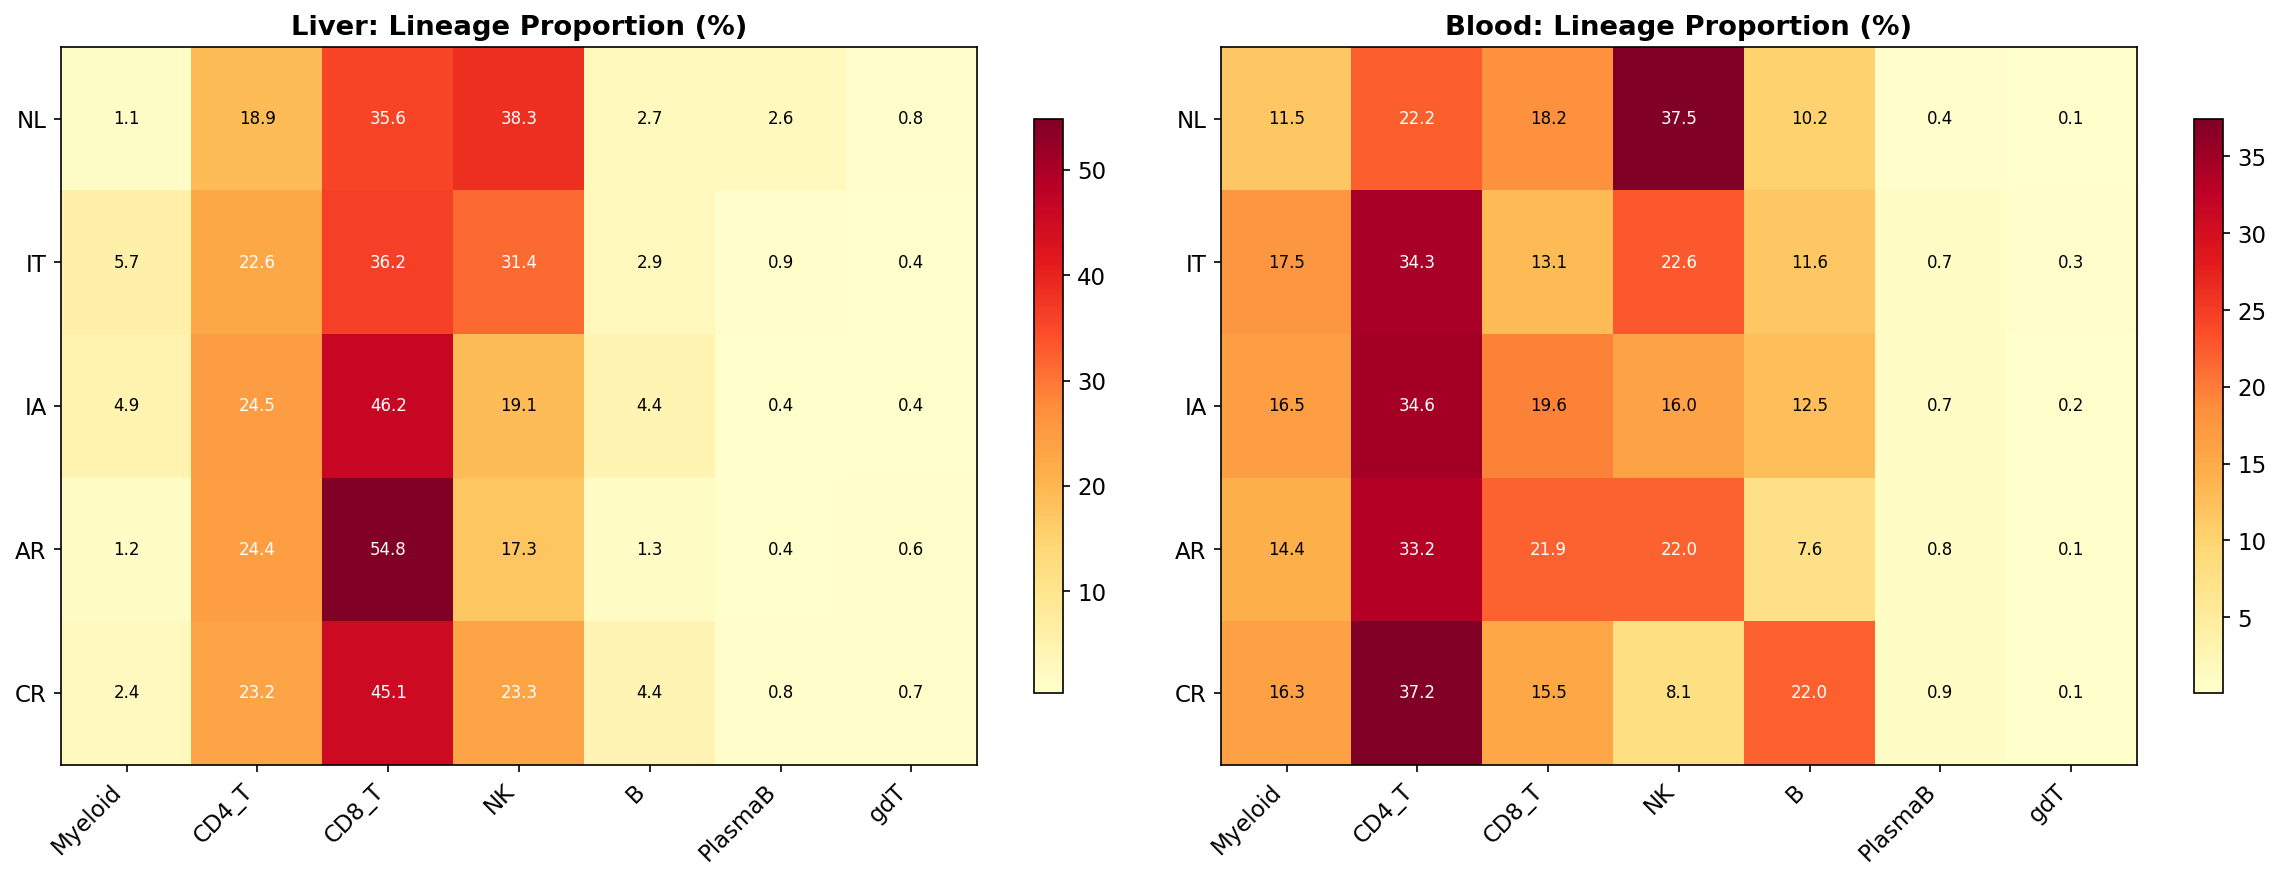

✅ Saved: fig_C0_4_lineage_heatmap_by_tissue.png


In [18]:
# ============================================================
# 11. VISUALIZATION: Tissue × Stage × Lineage
# ============================================================
print("\n" + "=" * 70)
print("GENERATING FIGURES...")
print("=" * 70)

# --- Figure 1: Cell count barplot by tissue and stage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, tissue in enumerate(['Liver', 'Blood']):
    mask = adata.obs['tissue'] == tissue
    prop = adata.obs[mask].groupby('Stage')['major_lineage'].value_counts(normalize=True).unstack(fill_value=0) * 100
    prop = prop.reindex(stage_order)

    lineage_order = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB', 'gdT']
    lineage_order = [l for l in lineage_order if l in prop.columns]
    prop = prop[lineage_order]

    prop.plot(kind='bar', stacked=True, ax=axes[i],
              colormap='Set2', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{tissue}: Lineage Proportions by Stage', fontweight='bold')
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('Disease Stage')
    axes[i].set_xticklabels(stage_order, rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/C0_data_framework/fig_C0_1_lineage_proportions_by_tissue.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C0_1_lineage_proportions_by_tissue.png")

# --- Figure 2: Liver vs Blood cell count comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
tissue_stage_plot = adata.obs.groupby(['Stage', 'tissue']).size().unstack(fill_value=0)
tissue_stage_plot = tissue_stage_plot.reindex(stage_order)
tissue_stage_plot.plot(kind='bar', ax=ax, color=['#E74C3C', '#3498DB'], edgecolor='white')
ax.set_title('Cell Counts: Liver vs Blood by Disease Stage', fontweight='bold')
ax.set_ylabel('Number of Cells')
ax.set_xlabel('Disease Stage')
ax.set_xticklabels(stage_order, rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', fontsize=8, padding=2)
ax.legend(['Blood', 'Liver'])
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/C0_data_framework/fig_C0_2_liver_blood_cellcounts.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C0_2_liver_blood_cellcounts.png")

# --- Figure 3: Liver:Blood ratio by stage ---
fig, ax = plt.subplots(figsize=(8, 5))
ratios = []
for stage in stage_order:
    liver_n = tissue_stage.loc['Liver', stage] if 'Liver' in tissue_stage.index and stage in tissue_stage.columns else 0
    blood_n = tissue_stage.loc['Blood', stage] if 'Blood' in tissue_stage.index and stage in tissue_stage.columns else 0
    ratios.append(liver_n / blood_n if blood_n > 0 else 0)
bars = ax.bar(stage_order, ratios, color=['#2ECC71', '#E74C3C', '#E67E22', '#3498DB', '#9B59B6'],
              edgecolor='white', linewidth=1.5)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Equal (1:1)')
ax.set_title('Liver:Blood Cell Ratio by Disease Stage', fontweight='bold')
ax.set_ylabel('Ratio (Liver / Blood)')
ax.set_xlabel('Disease Stage')
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{ratio:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/C0_data_framework/fig_C0_3_liver_blood_ratio.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C0_3_liver_blood_ratio.png")

# --- Figure 4: Heatmap - Lineage proportions Liver vs Blood ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, tissue in enumerate(['Liver', 'Blood']):
    mask = adata.obs['tissue'] == tissue
    prop = adata.obs[mask].groupby('Stage')['major_lineage'].value_counts(normalize=True).unstack(fill_value=0) * 100
    prop = prop.reindex(stage_order)
    lineage_order = [l for l in ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB', 'gdT'] if l in prop.columns]
    prop = prop[lineage_order]

    im = axes[i].imshow(prop.values, cmap='YlOrRd', aspect='auto')
    axes[i].set_xticks(range(len(lineage_order)))
    axes[i].set_xticklabels(lineage_order, rotation=45, ha='right')
    axes[i].set_yticks(range(len(stage_order)))
    axes[i].set_yticklabels(stage_order)
    axes[i].set_title(f'{tissue}: Lineage Proportion (%)', fontweight='bold')

    # Add text annotations
    for y in range(len(stage_order)):
        for x in range(len(lineage_order)):
            val = prop.values[y, x]
            axes[i].text(x, y, f'{val:.1f}', ha='center', va='center', fontsize=8,
                        color='white' if val > 20 else 'black')

    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/C0_data_framework/fig_C0_4_lineage_heatmap_by_tissue.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C0_4_lineage_heatmap_by_tissue.png")


In [19]:
# ============================================================
# 12. 169 GENES AVAILABILITY CHECK
# ============================================================
print("\n" + "=" * 70)
print("169 GENES AVAILABILITY CHECK")
print("=" * 70)

# C3 genes (152) + C3b genes (17) = 169
c3b_genes = ['AICDA', 'AIM2', 'CD27', 'CD38', 'IFNG', 'IGHG1', 'IL15', 'IL15RA',
             'IL1RN', 'JCHAIN', 'KLRF1', 'LAYN', 'MEFV', 'NLRC4', 'RICTOR', 'TNFAIP3', 'TOX2']

# Check which genes are in the dataset
available = [g for g in c3b_genes if g in adata.var_names]
missing = [g for g in c3b_genes if g not in adata.var_names]
print(f"\nC3b genes (17): {len(available)} available, {len(missing)} missing")
if missing:
    print(f"  Missing: {missing}")

# Check total gene availability (we'll verify C3 genes when the full list is loaded)
print(f"\nTotal genes in h5ad: {adata.n_vars}")
print(f"C3b genes available: {len(available)}/{len(c3b_genes)}")



169 GENES AVAILABILITY CHECK

C3b genes (17): 17 available, 0 missing

Total genes in h5ad: 24452
C3b genes available: 17/17


In [20]:
# ============================================================
# 13. SUMMARY REPORT
# ============================================================
print("\n" + "=" * 70)
print("v18-C0 SUMMARY REPORT")
print("=" * 70)

summary = f"""
v18-C0: DATA FRAMEWORK SUMMARY
{'='*50}
Dataset: GSE182159
Total cells: {adata.n_obs:,}
Total genes: {adata.n_vars:,}
Tissues: {sorted(adata.obs['tissue'].unique().tolist())}
Stages: {sorted(adata.obs['Stage'].unique().tolist())}
Donors: {adata.obs['donor'].nunique()}
Samples: {adata.obs['sample'].nunique()}
Lineages: {sorted(adata.obs['major_lineage'].unique().tolist())}

TISSUE DISTRIBUTION:
  Liver: {tissue_counts.get('Liver', 0):,} cells ({tissue_counts.get('Liver', 0)/adata.n_obs*100:.1f}%)
  Blood: {tissue_counts.get('Blood', 0):,} cells ({tissue_counts.get('Blood', 0)/adata.n_obs*100:.1f}%)

ANALYSIS PLAN:
  Primary: Liver-only analysis (169 genes × C0-C7)
  Secondary: Blood-only analysis (169 genes × C0-C7)
  Comparative: v17(combined) vs v18(Liver) vs v18(Blood)

SAVE PATH: {SAVE_DIR}

STATUS: ✅ C0 COMPLETE — Ready for C1
"""

print(summary)

# Save summary
with open(f'{SAVE_DIR}/C0_data_framework/C0_summary_report.txt', 'w') as f:
    f.write(summary)
print(f"✅ Saved: C0_summary_report.txt")


v18-C0 SUMMARY REPORT

v18-C0: DATA FRAMEWORK SUMMARY
Dataset: GSE182159
Total cells: 243,000
Total genes: 24,452
Tissues: ['Blood', 'Liver']
Stages: ['AR', 'CR', 'IA', 'IT', 'NL']
Donors: 23
Samples: 46
Lineages: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']

TISSUE DISTRIBUTION:
  Liver: 106,592 cells (43.9%)
  Blood: 136,408 cells (56.1%)

ANALYSIS PLAN:
  Primary: Liver-only analysis (169 genes × C0-C7)
  Secondary: Blood-only analysis (169 genes × C0-C7)
  Comparative: v17(combined) vs v18(Liver) vs v18(Blood)

SAVE PATH: /content/drive/MyDrive/ITLAS/results/version18-analysis/

STATUS: ✅ C0 COMPLETE — Ready for C1

✅ Saved: C0_summary_report.txt


In [21]:
# ============================================================
# 14. CRITICAL CHECK: Stage balance across tissues
# ============================================================
print("\n" + "=" * 70)
print("⚠️ CRITICAL CHECK: Stage balance across tissues")
print("=" * 70)
print("If Liver:Blood ratio varies dramatically by stage,")
print("v17 combined analysis may have tissue composition bias.\n")

for stage in stage_order:
    liver_n = tissue_stage.loc['Liver', stage] if 'Liver' in tissue_stage.index and stage in tissue_stage.columns else 0
    blood_n = tissue_stage.loc['Blood', stage] if 'Blood' in tissue_stage.index and stage in tissue_stage.columns else 0
    ratio = liver_n / blood_n if blood_n > 0 else float('inf')
    flag = " ⚠️ IMBALANCED" if ratio < 0.5 or ratio > 2.0 else " ✅"
    print(f"  {stage}: Liver:Blood = {ratio:.2f}{flag}")

print("\n" + "=" * 70)
print("v18-C0 COMPLETE")
print(f"All outputs saved to: {SAVE_DIR}/C0_data_framework/")
print("=" * 70)



⚠️ CRITICAL CHECK: Stage balance across tissues
If Liver:Blood ratio varies dramatically by stage,
v17 combined analysis may have tissue composition bias.

  NL: Liver:Blood = 1.32 ✅
  IT: Liver:Blood = 0.66 ✅
  IA: Liver:Blood = 1.07 ✅
  AR: Liver:Blood = 0.64 ✅
  CR: Liver:Blood = 0.42 ⚠️ IMBALANCED

v18-C0 COMPLETE
All outputs saved to: /content/drive/MyDrive/ITLAS/results/version18-analysis//C0_data_framework/
